In [1]:
# Import Tools:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

# IMPORT DATA
df_match = pd.read_csv(r'F:\ALMACENAMIENTO\DATA ANALITYCS\PORTAFOLIO\AI_Assistant_Hotels\SQL_ENRICHMENT\data_interaction__handling_hotel_match_features.csv', encoding='latin-1',dtype={'resolved': str})
df_full = pd.read_csv(r'F:\ALMACENAMIENTO\DATA ANALITYCS\PORTAFOLIO\AI_Assistant_Hotels\SQL_ENRICHMENT\data_interaction_hotel_full_features.csv',encoding='latin-1')


# Fix timestamp --> datetime
df_full['timestamp'] = pd.to_datetime(df_full['timestamp'], dayfirst=True)
df_match['timestamp'] = pd.to_datetime(df_match['timestamp'], dayfirst=True)

# Fix resolved en df_match
df_match['resolved'] = df_match['resolved'].map(
    {'True': True, 'False': False, 'TRUE': True, 'FALSE': False}
)

In [3]:
df_full.head(5)

,interaction_id,hotel_id,channel,language,request_type,complexity,hotel_name,city,country,hotel_type,rooms,hotel_size_category,timestamp,day_of_week,hour_of_day,day_of_week_number,time_period,month_number,month_name,quarter
0,INT2025_01_0001,hotel_01,website_chat,NO,info,simple,The Well,Sandvika,Norway,spa,231.0,Large,2025-01-03 08:12:00,Friday,8,5,Morning,1,January,1
1,INT2025_01_0002,hotel_01,email,EN,booking,complex,The Well,Sandvika,Norway,spa,231.0,Large,2025-01-03 08:25:00,Friday,8,5,Morning,1,January,1
2,INT2025_01_0003,hotel_03,facebook,NO,service_request,simple,Fjord Spa Hotel,Flåm,Norway,spa,95.0,Small,2025-01-04 09:02:00,Saturday,9,6,Morning,1,January,1
3,INT2025_01_0004,hotel_07,instagram,EN,complaint,complex,Trondheim Central Hotel,Trondheim,Norway,city,140.0,Large,2025-01-04 10:45:00,Saturday,10,6,Morning,1,January,1
4,INT2025_01_0005,hotel_02,email,NO,check_in,simple,Oslo City Hotel,Oslo,Norway,city,180.0,Large,2025-01-05 11:10:00,Sunday,11,0,Morning,1,January,1


C:\Users\Naomi\AppData\Local\Temp\ipykernel_18800\1319806597.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_count_hotel, x='count', y='hotel_name', palette='Blues_r')


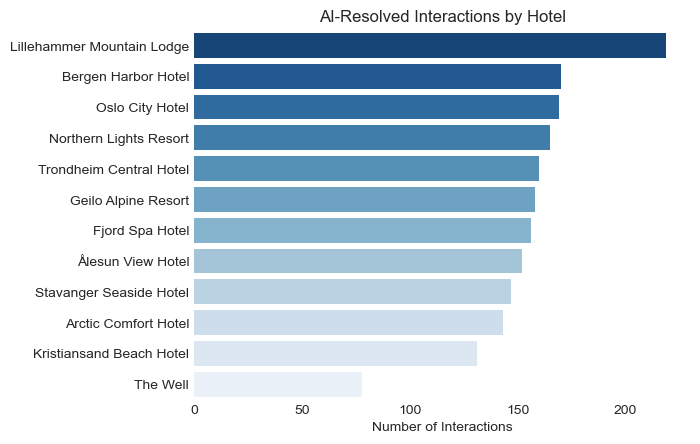

In [10]:
# Total interactions by hotel

df_ai_resolved = df_match[
    (df_match['handled_by'] == 'AI') & 
    (df_match['resolved'] == True)
]

df_count_hotel = df_ai_resolved.groupby('hotel_name').size().reset_index(name='count').sort_values(by='count', ascending=False)




sns.barplot(data=df_count_hotel, x='count', y='hotel_name', palette='Blues_r')
plt.title('AI-Resolved Interactions by Hotel')
plt.xlabel('Number of Interactions')
plt.ylabel('')

# Quitar fondo
plt.gca().set_facecolor('none')
plt.gcf().patch.set_alpha(0)

plt.show()

C:\Users\Naomi\AppData\Local\Temp\ipykernel_18800\324127973.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_count_channel, x='count', y='channel', palette='Blues_r')


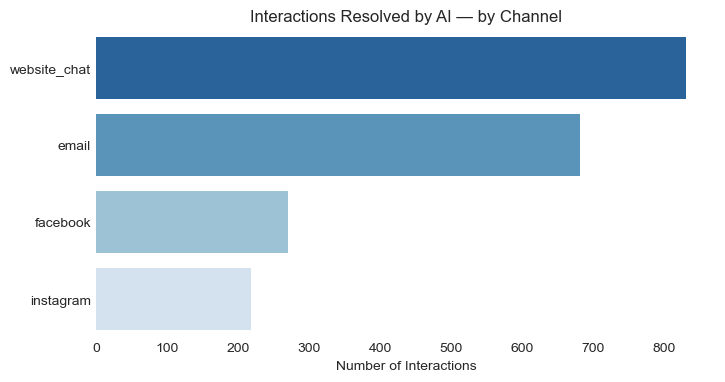

In [4]:
# Distribution by channel — AI resolved only

MIN_INTERACTIONS = 3

df_ai_resolved = df_match[
    (df_match['handled_by'] == 'AI') & 
    (df_match['resolved'] == True)
]

df_count_channel = (
    df_ai_resolved
    .groupby('channel')
    .size()
    .reset_index(name='count')
    .query('count >= @MIN_INTERACTIONS')
    .sort_values(by='count', ascending=False)
)



plt.figure(figsize=(8, 4), facecolor='white')
sns.barplot(data=df_count_channel, x='count', y='channel', palette='Blues_r')
plt.title('Interactions Resolved by AI — by Channel')
plt.xlabel('Number of Interactions')
plt.ylabel('')
ax = plt.gca()
ax.set_facecolor('white')

C:\Users\Naomi\AppData\Local\Temp\ipykernel_13404\410179047.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Text(0, 0.5, '')

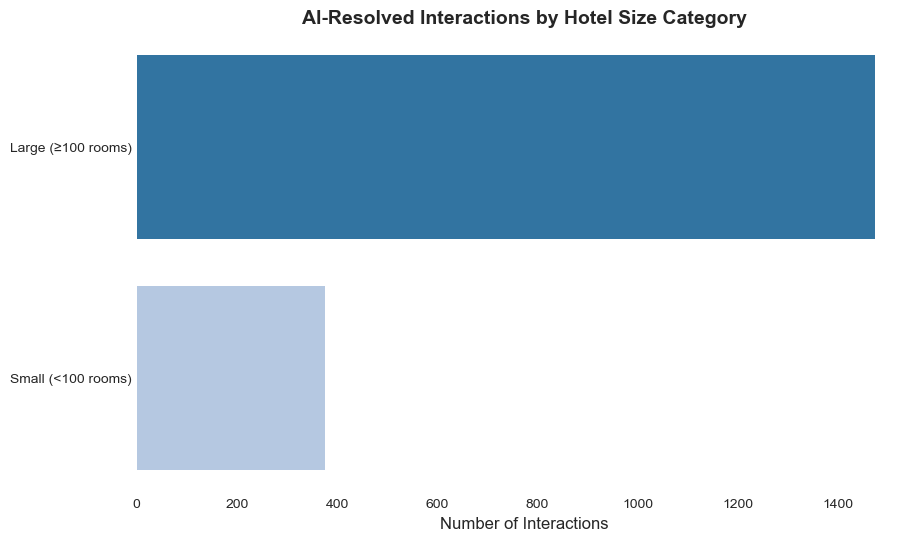

In [15]:
# Prepare data
df_count_hotel_size = df_ai_resolved.groupby('hotel_size_category').size().reset_index(name='count').sort_values(by='count', ascending=False)

# Add descriptive labels
df_count_hotel_size['category_label'] = df_count_hotel_size['hotel_size_category'].map({
    'Small': 'Small (<100 rooms)',
    'Large': 'Large (≥100 rooms)'
})

# Create bar chart


plt.figure(figsize=(10, 6), facecolor='white')
sns.barplot(
    data=df_count_hotel_size, 
    x='count', 
    y='category_label',
    palette='tab20'
)
ax = plt.gca()
ax.set_facecolor('white')
plt.title('AI-Resolved Interactions by Hotel Size Category', fontsize=14, fontweight='bold')
plt.xlabel('Number of Interactions', fontsize=12)
plt.ylabel('')

C:\Users\Naomi\AppData\Local\Temp\ipykernel_13404\4121255073.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_count_request_type, x='count', y='request_type', palette='Blues_r')


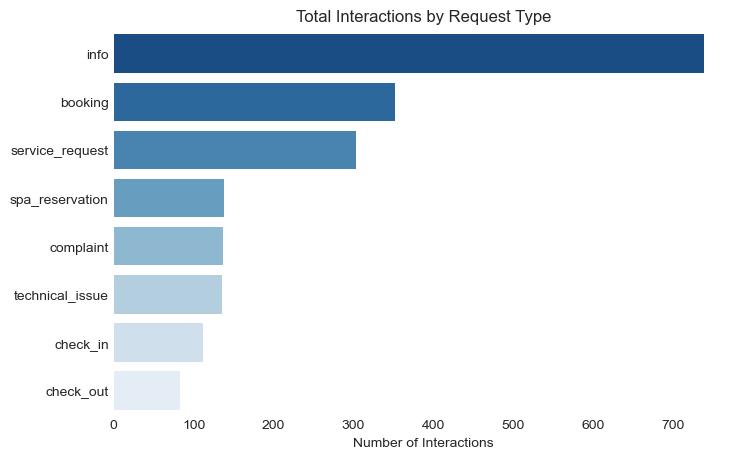

In [14]:
# Distribution by request_type
MIN_INTERACTIONS1 = 3

df_count_request_type = df_ai_resolved.groupby('request_type').size().reset_index(name='count').query('count >= @MIN_INTERACTIONS1').sort_values(by='count', ascending=False)

plt.figure(figsize=(8, 5), facecolor='white')
sns.barplot(data=df_count_request_type, x='count', y='request_type', palette='Blues_r')
ax = plt.gca()
ax.set_facecolor('white')
plt.title('Total Interactions by Request Type')
plt.xlabel('Number of Interactions')
plt.ylabel('')
plt.show()

C:\Users\Naomi\AppData\Local\Temp\ipykernel_13404\1026276201.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_count_complexity, x='count', y='complexity', palette='Blues_r')


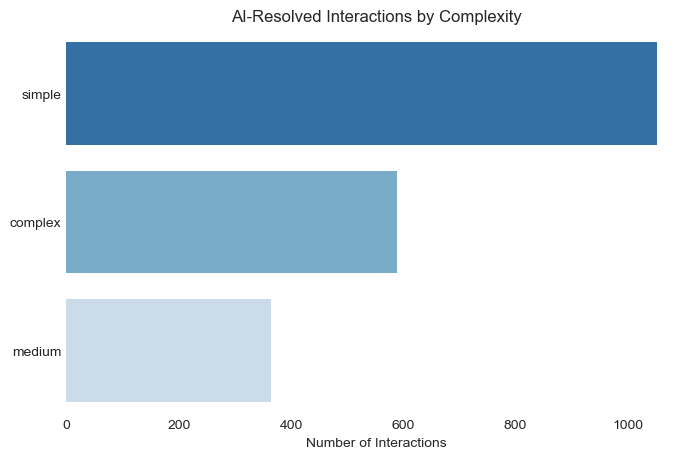

In [17]:
# Distribution by Complexity

df_count_complexity = df_ai_resolved.groupby('complexity').size().reset_index(name='count').sort_values(by='count', ascending=False)

plt.figure(figsize=(8, 5), facecolor='white')
sns.barplot(data=df_count_complexity, x='count', y='complexity', palette='Blues_r')
ax = plt.gca()
ax.set_facecolor('white')
plt.title('AI-Resolved Interactions by Complexity')
plt.xlabel('Number of Interactions')
plt.ylabel('')
plt.show()

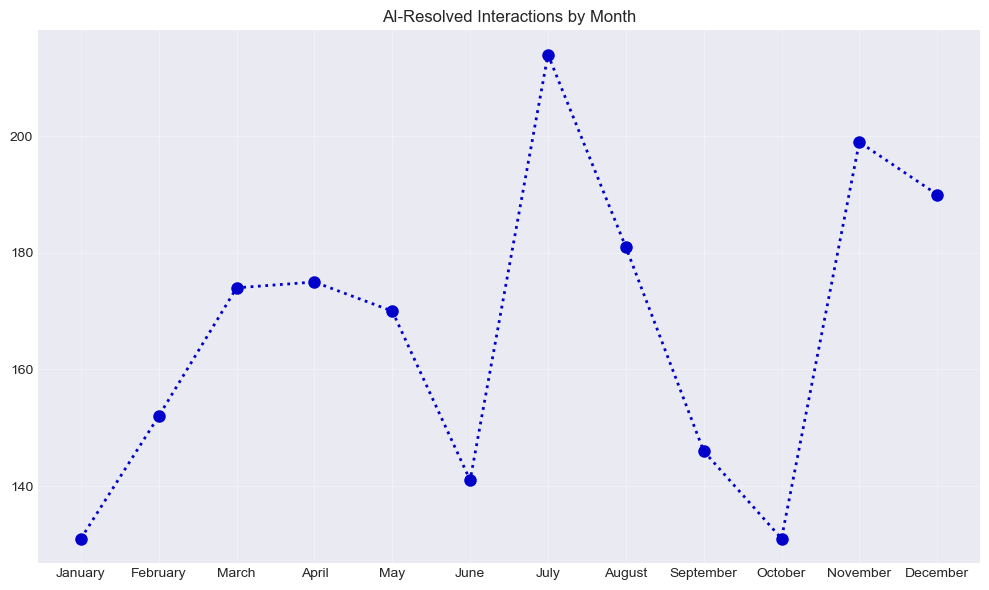

In [19]:
# 1.2.1 Volume by month (line chart)

df_count_month = df_ai_resolved.groupby(['month_number', 'month_name']).size().reset_index(name='count')
df_count_month = df_count_month.sort_values(by='month_number')

df_count_month['month_label'] = df_count_month['month_name']


plt.figure(figsize=(10, 6))
plt.plot(
    df_count_month['month_label'], 
    df_count_month['count'], 
    marker='o',
    color='mediumblue',
    linestyle=':', 
    linewidth=2, 
    markersize=8)
plt.title('AI-Resolved Interactions by Month')
plt.xlabel('')
plt.ylabel('')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
heatmap_data = df_full.groupby(['hour_of_day', 'day_of_week']).size().reset_index(name='count')
heatmap_data.sort_values(by=['count'], ascending=False)


,hour_of_day,day_of_week,count
44,13,Friday,91
29,10,Wednesday,87
27,10,Thursday,85
23,10,Friday,85
46,13,Saturday,82
...,...,...,...
1,3,Tuesday,3
80,18,Monday,2
0,3,Sunday,1
81,18,Sunday,1


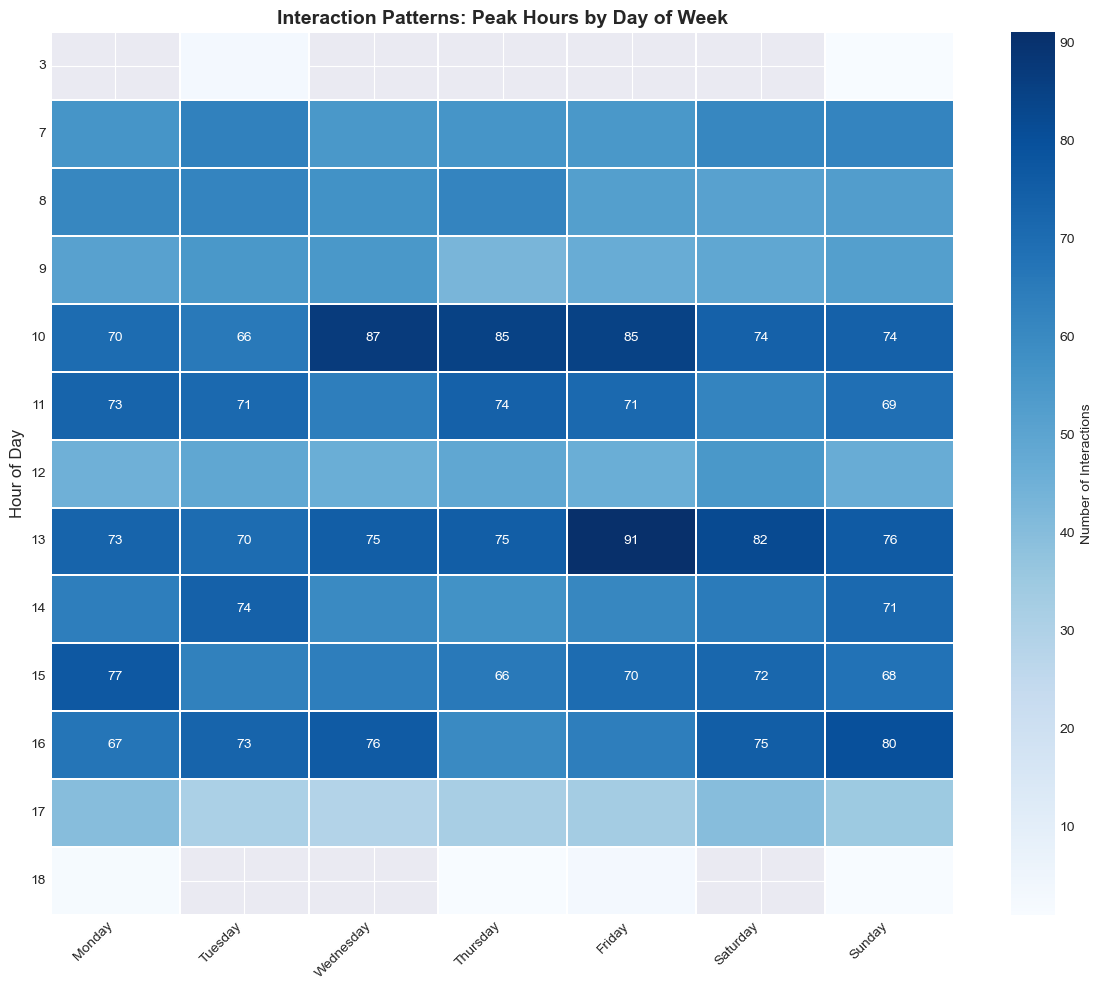

In [10]:
# ==========================================
# HEATMAP: Solo mostrar números > 80
# ==========================================

# PASO 1: Crear tabla pivote
heatmap_data = df_full.groupby(['hour_of_day', 'day_of_week']).size().reset_index(name='count')
heatmap_pivot = heatmap_data.pivot(index='hour_of_day', columns='day_of_week', values='count')

# PASO 2: Ordenar días de semana
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_pivot = heatmap_pivot[day_order]

# PASO 3: Crear matriz de anotaciones (solo valores > 86)
threshold = 65
annot_matrix = heatmap_pivot.map(lambda x: str(int(x)) if x > threshold else '')
                            # ↑ Cambiar applymap → map

# PASO 4: Crear heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    heatmap_pivot, 
    cmap='Blues',
    annot=annot_matrix,      
    fmt='',                  
    cbar_kws={'label': 'Number of Interactions'},
    linewidths=0.05,
    linecolor='white'
)

plt.title('Interaction Patterns: Peak Hours by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('', fontsize=12)
plt.ylabel('Hour of Day', fontsize=12)
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

C:\Users\Naomi\AppData\Local\Temp\ipykernel_53148\174556966.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=city_counts.index, x=city_counts.values, palette='viridis')


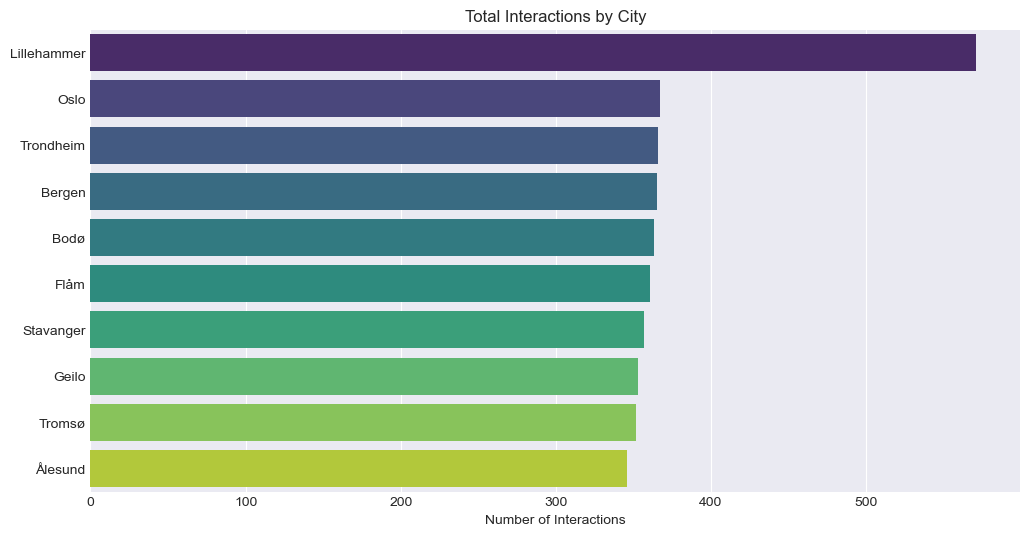

In [11]:
# No necesita squarify
plt.figure(figsize=(12, 6))
city_counts = df_full['city'].value_counts().head(10)
sns.barplot(y=city_counts.index, x=city_counts.values, palette='viridis')
plt.title('Total Interactions by City')
plt.xlabel('Number of Interactions')
plt.ylabel('')
plt.show()

<Figure size 1200x800 with 0 Axes>

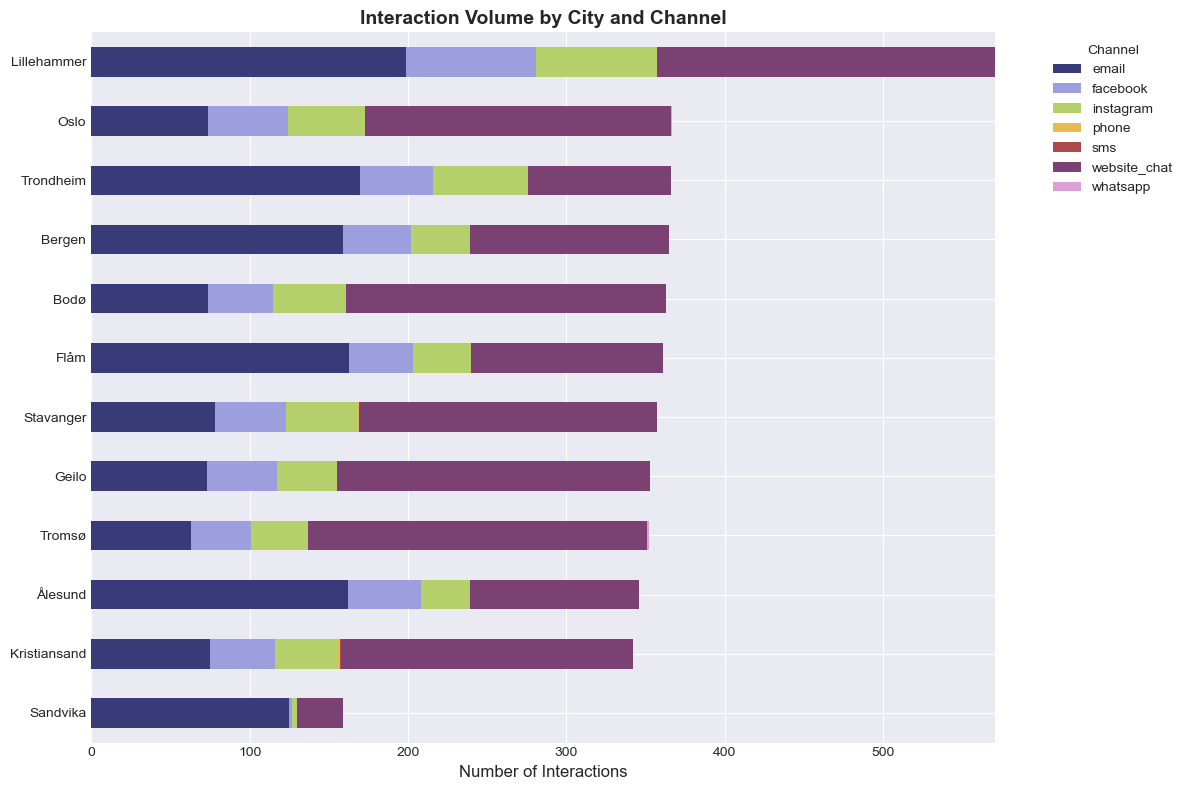

In [12]:
# ==========================================
# SEGMENTATION: City x Channel
# ==========================================

# Preparar datos
city_channel = df_full.groupby(['city', 'channel']).size().reset_index(name='count')

# Pivotar
city_channel_pivot = city_channel.pivot(index='city', columns='channel', values='count')

# Ordenar por total de interacciones
city_channel_pivot['total'] = city_channel_pivot.sum(axis=1)
city_channel_pivot = city_channel_pivot.sort_values('total', ascending=True).drop('total', axis=1)

# Crear stacked bar chart
plt.figure(figsize=(12, 8))
city_channel_pivot.plot(
    kind='barh', 
    stacked=True, 
    figsize=(12, 8),
    colormap='tab20b'
)

plt.title('Interaction Volume by City and Channel', fontsize=14, fontweight='bold')
plt.xlabel('Number of Interactions', fontsize=12)
plt.ylabel('')
plt.legend(title='Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Mostrar tabla de porcentajes
# city_channel_pct = city_channel_pivot.div(city_channel_pivot.sum(axis=1), axis=0) * 100
# print("\nChannel distribution by city (%):")
# print(city_channel_pct.round(1))


In [13]:
df_match.head(5)

,interaction_id,hotel_id,timestamp,channel,language,request_type,complexity,hotel_name,city,country,hotel_type,rooms,hotel_size_category,handled_by,response_time_s,response_speed,hour_of_day,day_of_week_number,day_of_week,month_number,month_name,quarter,time_period,resolved
0,INT2025_01_0001,hotel_01,2025-01-03 08:12:00,website_chat,NO,info,simple,The Well,Sandvika,Norway,spa,231.0,Large,AI,6.2,Fast,8,5,Friday,1,January,1,Morning,True
1,INT2025_01_0002,hotel_01,2025-01-03 08:25:00,email,EN,booking,complex,The Well,Sandvika,Norway,spa,231.0,Large,Human,185.4,Medium,8,5,Friday,1,January,1,Morning,True
2,INT2025_01_0003,hotel_03,2025-01-04 09:02:00,facebook,NO,service_request,simple,Fjord Spa Hotel,Flåm,Norway,spa,95.0,Small,AI,9.8,Fast,9,6,Saturday,1,January,1,Morning,True
3,INT2025_01_0004,hotel_07,2025-01-04 10:45:00,instagram,EN,complaint,complex,Trondheim Central Hotel,Trondheim,Norway,city,140.0,Large,Human,412.0,Slow,10,6,Saturday,1,January,1,Morning,True
4,INT2025_01_0005,hotel_02,2025-01-05 11:10:00,email,NO,check_in,simple,Oslo City Hotel,Oslo,Norway,city,180.0,Large,AI,7.1,Fast,11,0,Sunday,1,January,1,Morning,True


Response Time Statistics:
count    3267.000000
mean      175.156688
std       185.517241
min         4.700000
25%        21.500000
50%        60.000000
75%       360.000000
max       720.000000
Name: response_time_s, dtype: float64


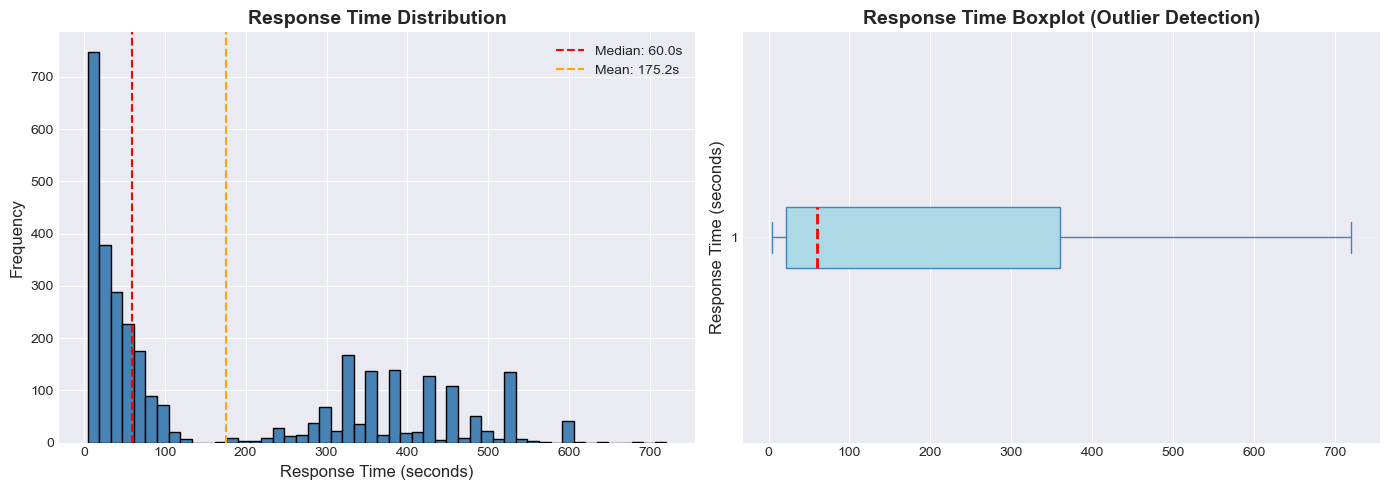

In [14]:
# ==========================================
# 2.1.1 Response Time Distribution
# ==========================================

# Estadísticas básicas
print("Response Time Statistics:")
print(df_match['response_time_s'].describe())

# Crear figura con subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Histogram
axes[0].hist(df_match['response_time_s'].dropna(), bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Response Time Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Response Time (seconds)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].axvline(df_match['response_time_s'].median(), color='red', linestyle='--', label=f'Median: {df_match["response_time_s"].median():.1f}s')
axes[0].axvline(df_match['response_time_s'].mean(), color='orange', linestyle='--', label=f'Mean: {df_match["response_time_s"].mean():.1f}s')
axes[0].legend()

# Subplot 2: Boxplot
# axes[1].boxplot(df_match['response_time_s'].dropna(), vert=False, color='red',linestyle='--')


bp = axes[1].boxplot(
    df_match['response_time_s'].dropna(), 
    vert=False,  # Horizontal
    patch_artist=True,  # Para poder colorear
    boxprops=dict(facecolor='lightblue', color='steelblue'),
    medianprops=dict(color='red',linestyle='--', linewidth=2),
    whiskerprops=dict(color='steelblue'),
    capprops=dict(color='steelblue'),
    flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.5)
)
axes[1].set_title('Response Time Boxplot (Outlier Detection)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Response Time (seconds)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# ==========================================
# OUTLIER DETECTION - IQR Method
# ==========================================

# Calcular IQR
Q1 = df_match['response_time_s'].quantile(0.25)
Q3 = df_match['response_time_s'].quantile(0.75)
IQR = Q3 - Q1

# Definir límites de outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identificar outliers
outliers = df_match[
    (df_match['response_time_s'] < lower_bound) | 
    (df_match['response_time_s'] > upper_bound)
]

# Estadísticas de outliers
print("="*60)
print("OUTLIER DETECTION (IQR Method)")
print("="*60)
print(f"\nQ1 (25th percentile): {Q1:.1f}s")
print(f"Q3 (75th percentile): {Q3:.1f}s")
print(f"IQR: {IQR:.1f}s")
print(f"\nLower bound: {lower_bound:.1f}s")
print(f"Upper bound: {upper_bound:.1f}s")
print(f"\nTotal interactions: {len(df_match)}")
print(f"Outliers detected: {len(outliers)} ({len(outliers)/len(df_match)*100:.1f}%)")
print(f"  - Below lower bound: {len(df_match[df_match['response_time_s'] < lower_bound])}")
print(f"  - Above upper bound: {len(df_match[df_match['response_time_s'] > upper_bound])}")

# Estadísticas de outliers
print(f"\nOutlier response time range: {outliers['response_time_s'].min():.1f}s - {outliers['response_time_s'].max():.1f}s")
print(f"Outlier median: {outliers['response_time_s'].median():.1f}s")
print(f"Outlier mean: {outliers['response_time_s'].mean():.1f}s")

# Ver características de outliers
print("\n" + "="*60)
print("OUTLIER CHARACTERISTICS")
print("="*60)

print("\nOutliers by handled_by:")
print(outliers['handled_by'].value_counts())

print("\nOutliers by complexity:")
print(outliers['complexity'].value_counts())

print("\nOutliers by response_speed:")
print(outliers['response_speed'].value_counts())

print("\nOutliers by channel:")
print(outliers['channel'].value_counts())

OUTLIER DETECTION (IQR Method)

Q1 (25th percentile): 21.5s
Q3 (75th percentile): 360.0s
IQR: 338.5s

Lower bound: -486.2s
Upper bound: 867.8s

Total interactions: 3292
Outliers detected: 0 (0.0%)
  - Below lower bound: 0
  - Above upper bound: 0

Outlier response time range: nans - nans
Outlier median: nans
Outlier mean: nans

OUTLIER CHARACTERISTICS

Outliers by handled_by:
Series([], Name: count, dtype: int64)

Outliers by complexity:
Series([], Name: count, dtype: int64)

Outliers by response_speed:
Series([], Name: count, dtype: int64)

Outliers by channel:
Series([], Name: count, dtype: int64)


In [16]:
# ==========================================
# EXTREME VALUES ANALYSIS (Percentile Method)
# ==========================================

# Identificar valores extremos por percentil
p95 = df_match['response_time_s'].quantile(0.95)
p99 = df_match['response_time_s'].quantile(0.99)

extreme_values = df_match[df_match['response_time_s'] > p95]

print("="*60)
print("EXTREME VALUES ANALYSIS (Top 5%)")
print("="*60)
print(f"\n95th percentile: {p95:.1f}s")
print(f"99th percentile: {p99:.1f}s")
print(f"Maximum: {df_match['response_time_s'].max():.1f}s")

print(f"\nExtreme values (>95th percentile): {len(extreme_values)} ({len(extreme_values)/len(df_match)*100:.1f}%)")
print(f"Extreme value range: {extreme_values['response_time_s'].min():.1f}s - {extreme_values['response_time_s'].max():.1f}s")
print(f"Extreme value median: {extreme_values['response_time_s'].median():.1f}s")
print(f"Extreme value mean: {extreme_values['response_time_s'].mean():.1f}s")

# Características de valores extremos
print("\n" + "="*60)
print("EXTREME VALUES CHARACTERISTICS")
print("="*60)

print("\nExtreme values by handled_by:")
print(extreme_values['handled_by'].value_counts())

print("\nExtreme values by complexity:")
print(extreme_values['complexity'].value_counts())

print("\nExtreme values by response_speed:")
print(extreme_values['response_speed'].value_counts())

print("\nExtreme values by channel:")
print(extreme_values['channel'].value_counts())

EXTREME VALUES ANALYSIS (Top 5%)

95th percentile: 520.0s
99th percentile: 600.0s
Maximum: 720.0s

Extreme values (>95th percentile): 59 (1.8%)
Extreme value range: 530.0s - 720.0s
Extreme value median: 600.0s
Extreme value mean: 597.0s

EXTREME VALUES CHARACTERISTICS

Extreme values by handled_by:
handled_by
Human    59
Name: count, dtype: int64

Extreme values by complexity:
complexity
complex    29
medium     19
simple     11
Name: count, dtype: int64

Extreme values by response_speed:
response_speed
Slow    59
Name: count, dtype: int64

Extreme values by channel:
channel
website_chat    23
instagram       20
email            9
facebook         7
Name: count, dtype: int64


C:\Users\Naomi\AppData\Local\Temp\ipykernel_13404\1406224555.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(labels)


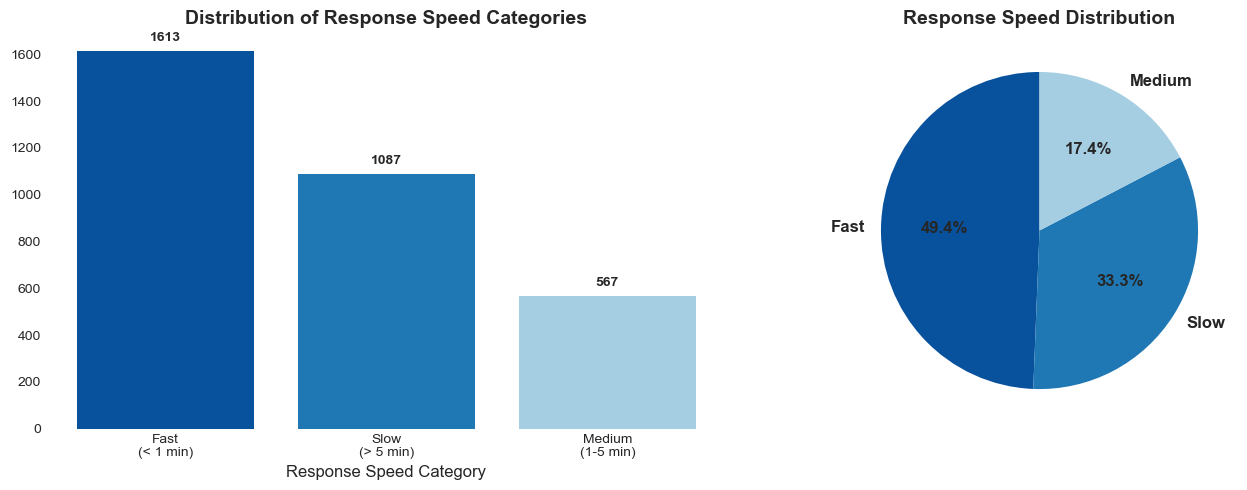

In [23]:
# Contar por categoría
speed_counts = df_match['response_speed'].value_counts()

# Crear visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

category_labels = {
    'Fast': 'Fast\n(< 1 min)',
    'Medium': 'Medium\n(1-5 min)',
    'Slow': 'Slow\n(> 5 min)'
}
labels = [category_labels[cat] for cat in speed_counts.index]

# Subplot 1: Bar chart
axes[0].set_facecolor('white')
axes[0].bar(speed_counts.index, speed_counts.values, color=['#08519c', '#1f78b4', '#a6cee3'])
axes[0].set_title('Distribution of Response Speed Categories', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Response Speed Category', fontsize=12)
axes[0].set_ylabel('')
axes[0].set_xticklabels(labels)

for i, (cat, val) in enumerate(speed_counts.items()):
    pct = (val / speed_counts.sum() * 100)
    axes[0].text(i, val + 30, f'{val}', ha='center', va='bottom', fontweight='bold')

# Subplot 2: Pie chart
axes[1].set_facecolor('white')
colors = ['#08519c', '#1f78b4', '#a6cee3']
axes[1].pie(
    speed_counts.values,
    labels=speed_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)
axes[1].set_title('Response Speed Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

AI vs HUMAN PERFORMANCE - RESPONSE TIME

AI responses: 2004 interactions
  Median: 28.0s
  Mean: 35.8s
  Min: 4.7s
  Max: 130.0s

Human responses: 1263 interactions
  Median: 380.0s
  Mean: 396.2s
  Min: 58.2s
  Max: 720.0s

Performance difference:
  Median: 352.0s (1257.1% slower)
  Mean: 360.4s (1005.6% slower)


C:\Users\Naomi\AppData\Local\Temp\ipykernel_53148\179849833.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


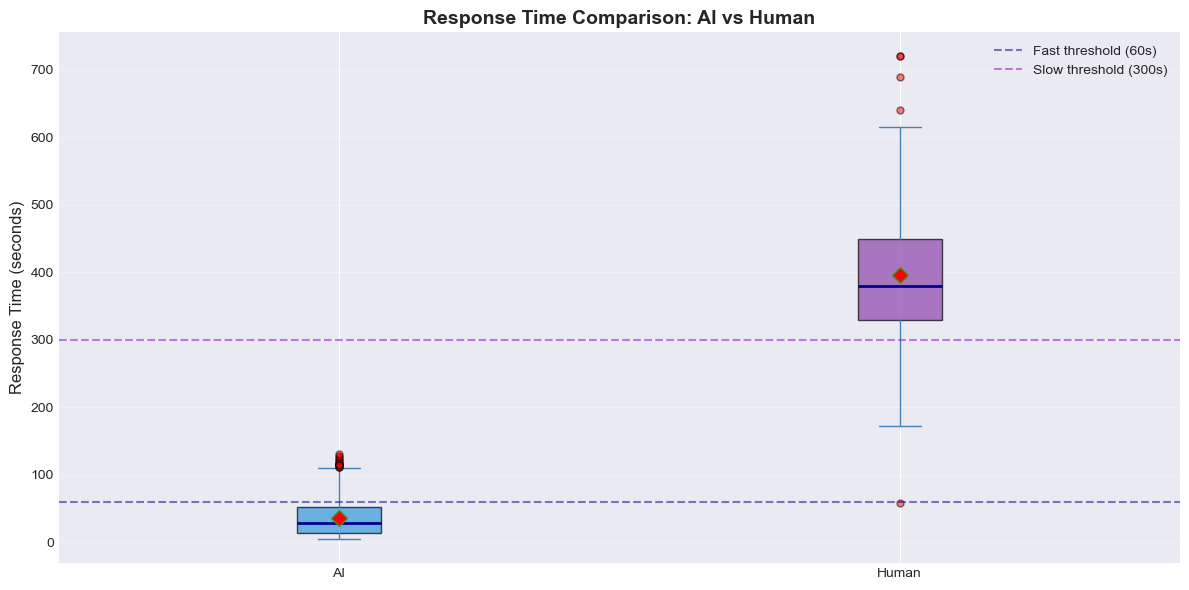

In [18]:
# ==========================================
# 2.2.1 Response Time: AI vs Human (Boxplot)
# ==========================================

# Filtrar datos por handler
ai_data = df_match[df_match['handled_by'] == 'AI']['response_time_s'].dropna()
human_data = df_match[df_match['handled_by'] == 'Human']['response_time_s'].dropna()

# Estadísticas básicas
print("="*60)
print("AI vs HUMAN PERFORMANCE - RESPONSE TIME")
print("="*60)
print(f"\nAI responses: {len(ai_data)} interactions")
print(f"  Median: {ai_data.median():.1f}s")
print(f"  Mean: {ai_data.mean():.1f}s")
print(f"  Min: {ai_data.min():.1f}s")
print(f"  Max: {ai_data.max():.1f}s")

print(f"\nHuman responses: {len(human_data)} interactions")
print(f"  Median: {human_data.median():.1f}s")
print(f"  Mean: {human_data.mean():.1f}s")
print(f"  Min: {human_data.min():.1f}s")
print(f"  Max: {human_data.max():.1f}s")

print(f"\nPerformance difference:")
print(f"  Median: {human_data.median() - ai_data.median():.1f}s ({((human_data.median() / ai_data.median()) - 1) * 100:.1f}% slower)")
print(f"  Mean: {human_data.mean() - ai_data.mean():.1f}s ({((human_data.mean() / ai_data.mean()) - 1) * 100:.1f}% slower)")

# Crear boxplot comparativo
plt.figure(figsize=(12, 6))

bp = plt.boxplot(
    [ai_data, human_data],
    labels=['AI', 'Human'],
    vert=True,
    patch_artist=True,
    showmeans=True,
    meanprops=dict(marker='D', markerfacecolor='red', markersize=8),
    medianprops=dict(color='darkblue', linewidth=2),
    boxprops=dict(facecolor='lightblue'),
    whiskerprops=dict(color='steelblue'),
    capprops=dict(color='steelblue'),
    flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.5)
)

# Colorear cajas diferentes
colors = ['#3498db', '#8e44ad']  # Azul (AI), Morado (Human)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title('Response Time Comparison: AI vs Human', fontsize=14, fontweight='bold')
plt.ylabel('Response Time (seconds)', fontsize=12)
plt.xlabel('')
plt.grid(axis='y', alpha=0.3)

# Agregar líneas de referencia
plt.axhline(y=60, color='darkblue', linestyle='--', alpha=0.5, label='Fast threshold (60s)')
plt.axhline(y=300, color='darkviolet', linestyle='--', alpha=0.5, label='Slow threshold (300s)')
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


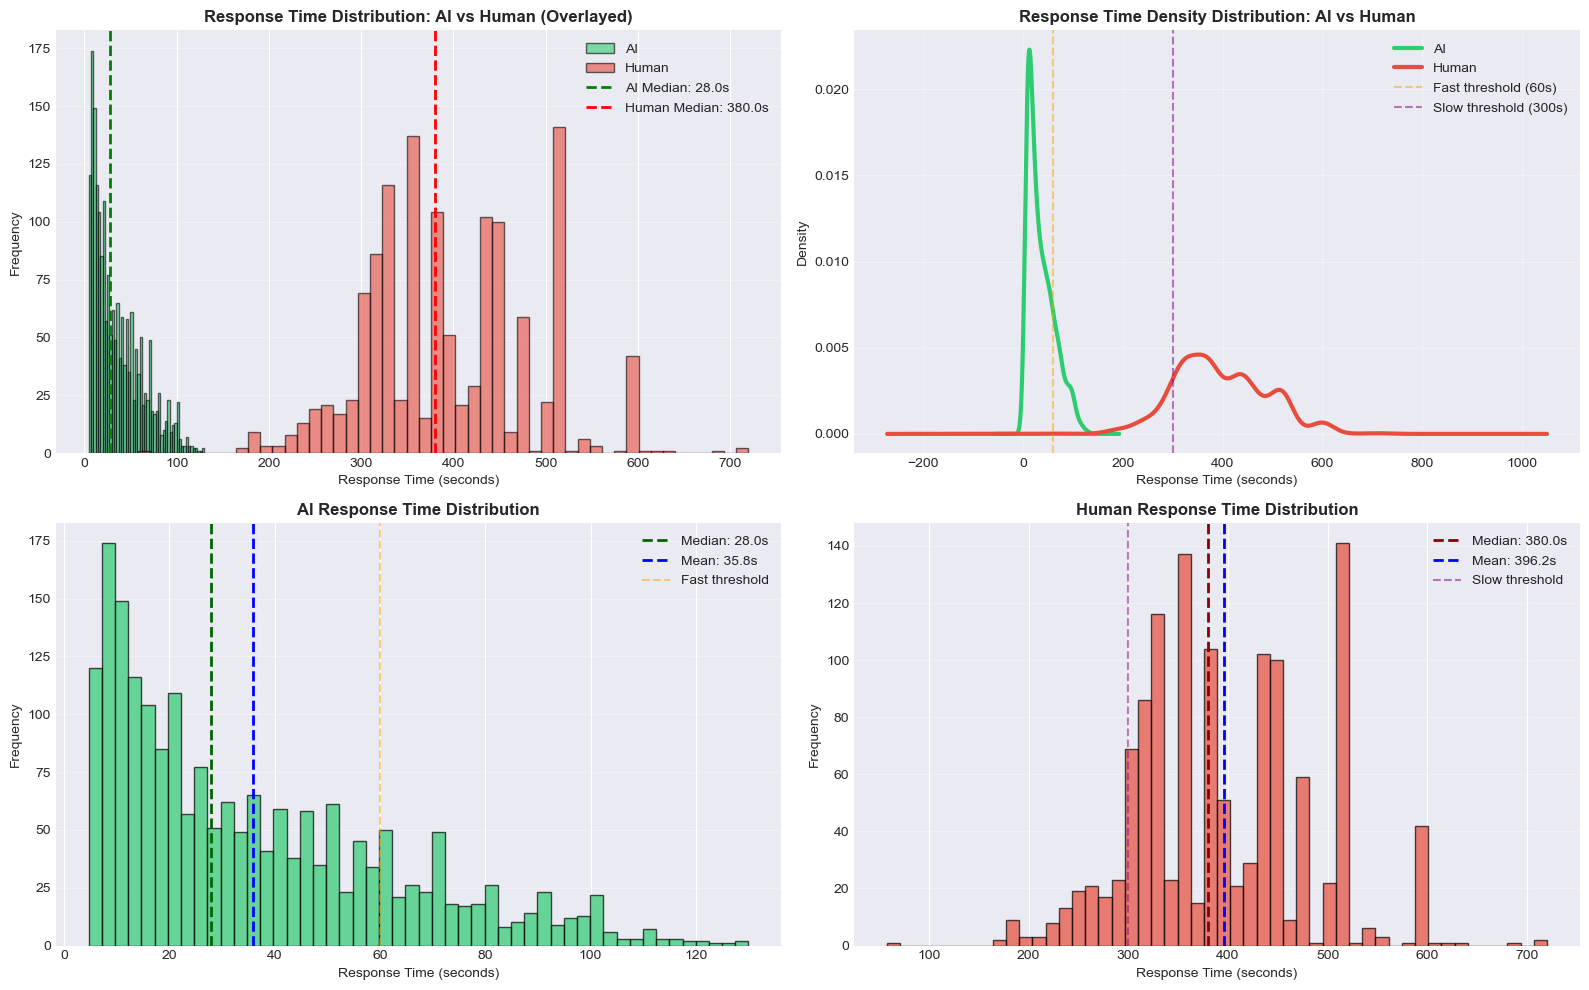

DISTRIBUTION STATISTICS

AI Distribution:
  Skewness: 0.96
  Std Dev: 26.7s
  Range: 4.7s - 130.0s

Human Distribution:
  Skewness: 0.29
  Std Dev: 90.6s
  Range: 58.2s - 720.0s


In [20]:
# ==========================================
# 2.2.2 Distribution Plots: AI vs Human
# ==========================================

# Preparar datos
ai_data = df_match[df_match['handled_by'] == 'AI']['response_time_s'].dropna()
human_data = df_match[df_match['handled_by'] == 'Human']['response_time_s'].dropna()

# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ===== SUBPLOT 1: Histograms Overlay =====
axes[0, 0].hist(ai_data, bins=50, alpha=0.6, color='#2ecc71', label='AI', edgecolor='black')
axes[0, 0].hist(human_data, bins=50, alpha=0.6, color='#e74c3c', label='Human', edgecolor='black')
axes[0, 0].set_title('Response Time Distribution: AI vs Human (Overlayed)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Response Time (seconds)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(ai_data.median(), color='green', linestyle='--', linewidth=2, label=f'AI Median: {ai_data.median():.1f}s')
axes[0, 0].axvline(human_data.median(), color='red', linestyle='--', linewidth=2, label=f'Human Median: {human_data.median():.1f}s')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# ===== SUBPLOT 2: KDE (Density) Plots =====
ai_data.plot.kde(ax=axes[0, 1], color= '#2ecc71', linewidth=3, label='AI')
human_data.plot.kde(ax=axes[0, 1], color='#e74c3c', linewidth=3, label='Human')
axes[0, 1].set_title('Response Time Density Distribution: AI vs Human', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Response Time (seconds)')
axes[0, 1].set_ylabel('Density')
axes[0, 1].axvline(60, color='orange', linestyle='--', alpha=0.5, label='Fast threshold (60s)')
axes[0, 1].axvline(300, color='purple', linestyle='--', alpha=0.5, label='Slow threshold (300s)')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# ===== SUBPLOT 3: Separate Histograms - AI =====
axes[1, 0].hist(ai_data, bins=50, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('AI Response Time Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Response Time (seconds)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(ai_data.median(), color='darkgreen', linestyle='--', linewidth=2, label=f'Median: {ai_data.median():.1f}s')
axes[1, 0].axvline(ai_data.mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {ai_data.mean():.1f}s')
axes[1, 0].axvline(60, color='orange', linestyle='--', alpha=0.5, label='Fast threshold')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# ===== SUBPLOT 4: Separate Histograms - Human =====
axes[1, 1].hist(human_data, bins=50, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Human Response Time Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Response Time (seconds)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(human_data.median(), color='darkred', linestyle='--', linewidth=2, label=f'Median: {human_data.median():.1f}s')
axes[1, 1].axvline(human_data.mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {human_data.mean():.1f}s')
axes[1, 1].axvline(300, color='purple', linestyle='--', alpha=0.5, label='Slow threshold')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas adicionales
print("="*60)
print("DISTRIBUTION STATISTICS")
print("="*60)
print(f"\nAI Distribution:")
print(f"  Skewness: {ai_data.skew():.2f}")
print(f"  Std Dev: {ai_data.std():.1f}s")
print(f"  Range: {ai_data.min():.1f}s - {ai_data.max():.1f}s")

print(f"\nHuman Distribution:")
print(f"  Skewness: {human_data.skew():.2f}")
print(f"  Std Dev: {human_data.std():.1f}s")
print(f"  Range: {human_data.min():.1f}s - {human_data.max():.1f}s")

RESOLUTION RATE: AI vs HUMAN

AI:
  Total: 2029
  Resolved: 2004 (98.8%)
  Unresolved: 19 (0.9%)

Human:
  Total: 1263
  Resolved: 921 (72.9%)
  Unresolved: 342 (27.1%)


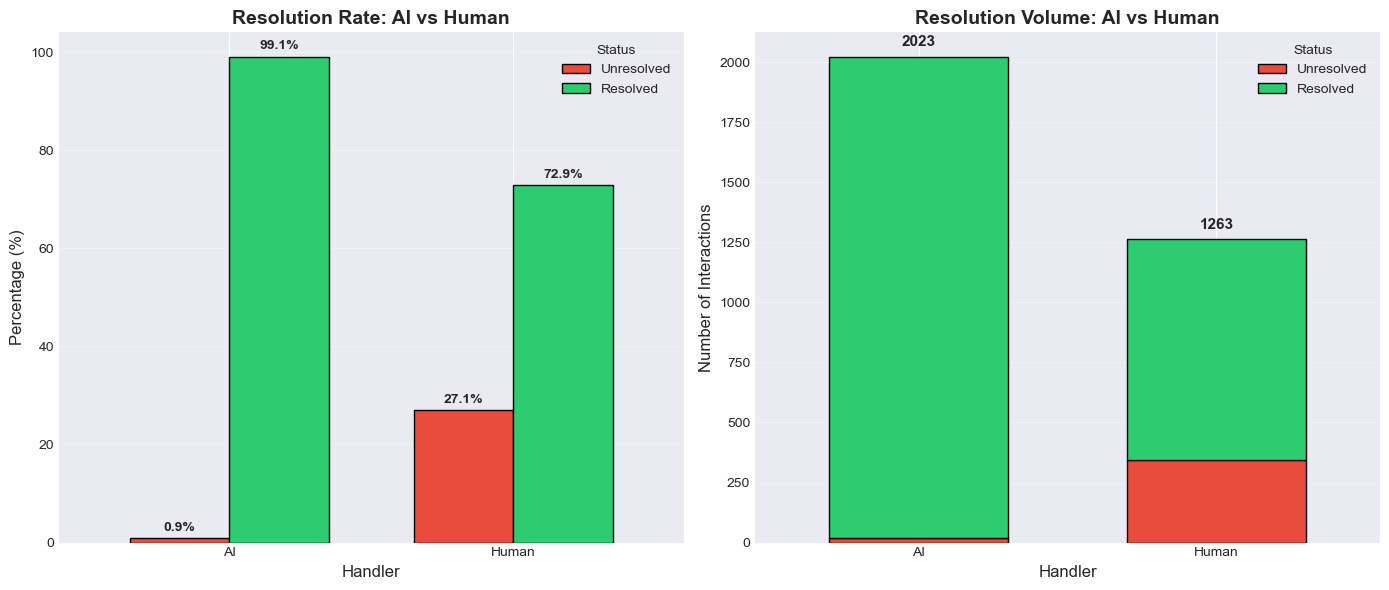

In [21]:
# ==========================================
# 2.2.3 Resolution Rate: AI vs Human
# ==========================================

# Calcular resolution rates
resolution_data = df_match.groupby(['handled_by', 'resolved']).size().reset_index(name='count')

# Calcular porcentajes
resolution_pct = df_match.groupby('handled_by')['resolved'].value_counts(normalize=True).unstack() * 100

# Estadísticas
print("="*60)
print("RESOLUTION RATE: AI vs HUMAN")
print("="*60)

for handler in ['AI', 'Human']:
    total = df_match[df_match['handled_by'] == handler].shape[0]
    resolved = df_match[(df_match['handled_by'] == handler) & (df_match['resolved'] == True)].shape[0]
    unresolved = df_match[(df_match['handled_by'] == handler) & (df_match['resolved'] == False)].shape[0]
    
    print(f"\n{handler}:")
    print(f"  Total: {total}")
    print(f"  Resolved: {resolved} ({resolved/total*100:.1f}%)")
    print(f"  Unresolved: {unresolved} ({unresolved/total*100:.1f}%)")

# Crear visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ===== SUBPLOT 1: Grouped Bar Chart =====
resolution_pct.plot(
    kind='bar',
    ax=axes[0],
    color=['#e74c3c', '#2ecc71'],  # Rojo (False), Verde (True)
    edgecolor='black',
    width=0.7
)
axes[0].set_title('Resolution Rate: AI vs Human', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Handler', fontsize=12)
axes[0].set_ylabel('Percentage (%)', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(['Unresolved', 'Resolved'], title='Status')
axes[0].grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', padding=3, fontweight='bold')

# ===== SUBPLOT 2: Stacked Bar (absolute numbers) =====
resolution_counts = df_match.groupby(['handled_by', 'resolved']).size().unstack()
resolution_counts.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black',
    width=0.6
)
axes[1].set_title('Resolution Volume: AI vs Human', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Handler', fontsize=12)
axes[1].set_ylabel('Number of Interactions', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(['Unresolved', 'Resolved'], title='Status')
axes[1].grid(axis='y', alpha=0.3)

# Agregar totales en la parte superior
for i, handler in enumerate(resolution_counts.index):
    total = resolution_counts.loc[handler].sum()
    axes[1].text(i, total + 30, f'{int(total)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

RESPONSE TIME BY COMPLEXITY

Simple:
  Count: 1673
  Median: 55.0s
  Mean: 162.6s
  Std Dev: 178.7s

Medium:
  Count: 602
  Median: 60.0s
  Mean: 193.2s
  Std Dev: 195.8s

Complex:
  Count: 992
  Median: 66.0s
  Mean: 185.4s
  Std Dev: 189.0s


C:\Users\Naomi\AppData\Local\Temp\ipykernel_53148\1527382933.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(
C:\Users\Naomi\AppData\Local\Temp\ipykernel_53148\1527382933.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Naomi\AppData\Local\Temp\ipykernel_53148\1527382933.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels([c.capitalize() for c in complexity_order])


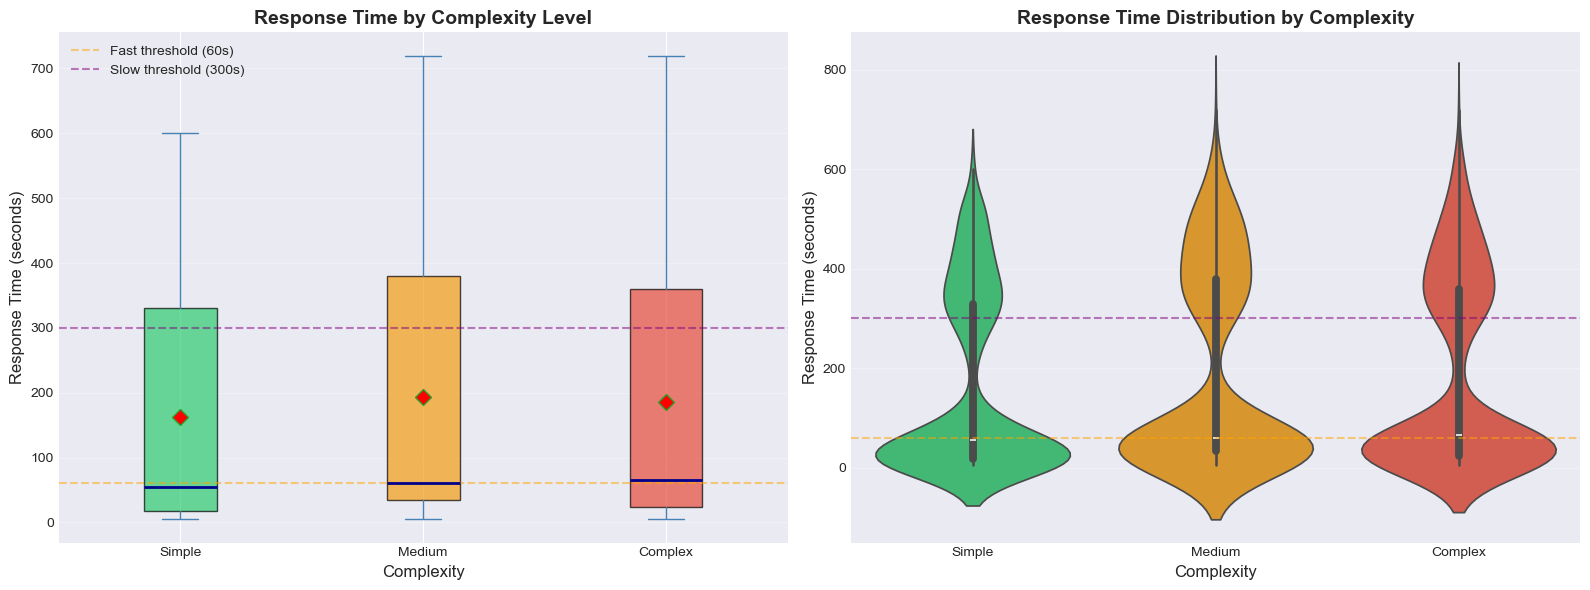

In [22]:
# ==========================================
# 2.3.1 Response Time vs Complexity
# ==========================================

# Estadísticas por complejidad
print("="*60)
print("RESPONSE TIME BY COMPLEXITY")
print("="*60)

for complexity in ['simple', 'medium', 'complex']:
    data = df_match[df_match['complexity'] == complexity]['response_time_s'].dropna()
    print(f"\n{complexity.capitalize()}:")
    print(f"  Count: {len(data)}")
    print(f"  Median: {data.median():.1f}s")
    print(f"  Mean: {data.mean():.1f}s")
    print(f"  Std Dev: {data.std():.1f}s")

# Crear visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ===== SUBPLOT 1: Boxplot by Complexity =====
complexity_order = ['simple', 'medium', 'complex']
df_match_clean = df_match[df_match['complexity'].notna() & df_match['response_time_s'].notna()]

bp = axes[0].boxplot(
    [df_match_clean[df_match_clean['complexity'] == c]['response_time_s'] for c in complexity_order],
    labels=[c.capitalize() for c in complexity_order],
    patch_artist=True,
    showmeans=True,
    meanprops=dict(marker='D', markerfacecolor='red', markersize=8),
    medianprops=dict(color='darkblue', linewidth=2),
    boxprops=dict(facecolor='lightblue'),
    whiskerprops=dict(color='steelblue'),
    capprops=dict(color='steelblue'),
    flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.5)
)

# Colorear cajas por complejidad
colors = ['#2ecc71', '#f39c12', '#e74c3c']  # Verde, Naranja, Rojo
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_title('Response Time by Complexity Level', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Response Time (seconds)', fontsize=12)
axes[0].set_xlabel('Complexity', fontsize=12)
axes[0].axhline(y=60, color='orange', linestyle='--', alpha=0.5, label='Fast threshold (60s)')
axes[0].axhline(y=300, color='purple', linestyle='--', alpha=0.5, label='Slow threshold (300s)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# ===== SUBPLOT 2: Violin Plot =====
sns.violinplot(
    data=df_match_clean,
    x='complexity',
    y='response_time_s',
    order=complexity_order,
    palette=['#2ecc71', '#f39c12', '#e74c3c'],
    ax=axes[1]
)
axes[1].set_title('Response Time Distribution by Complexity', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Response Time (seconds)', fontsize=12)
axes[1].set_xlabel('Complexity', fontsize=12)
axes[1].set_xticklabels([c.capitalize() for c in complexity_order])
axes[1].axhline(y=60, color='orange', linestyle='--', alpha=0.5)
axes[1].axhline(y=300, color='purple', linestyle='--', alpha=0.5)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

RESPONSE TIME BY HOUR OF DAY

Peak hours (highest median response time):
    hour_of_day  median  count
12           18   560.0      7
0             3   245.6      3
9            15   100.0    337
11           17   100.0    163
4            10    74.0    370

Best hours (lowest median response time):
    hour_of_day  median  count
1             7    37.5    284
2             8    39.0    284
6            12    58.0    227
10           16    58.0    338
7            13    59.0    384


C:\Users\Naomi\AppData\Local\Temp\ipykernel_53148\2163501327.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(


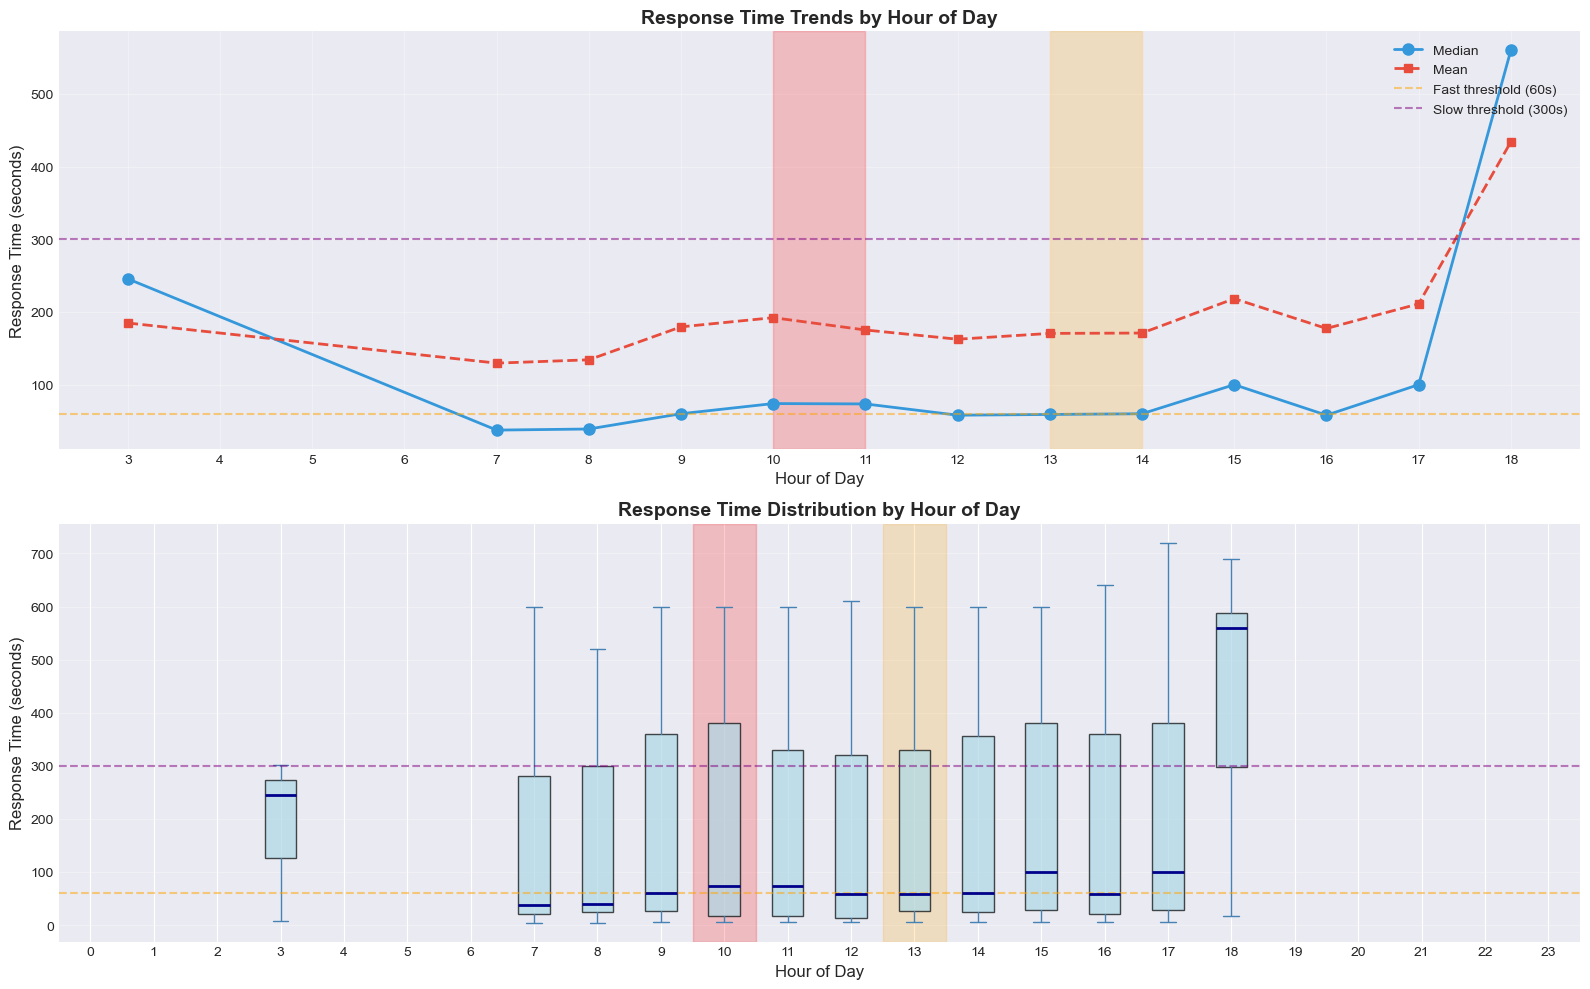


Interaction volume by hour:
 hour_of_day  count
           3      3
           7    284
           8    284
           9    249
          10    370
          11    328
          12    227
          13    384
          14    293
          15    337
          16    338
          17    163
          18      7


In [23]:
# ==========================================
# 2.3.2 Response Time vs Hour of Day
# ==========================================

# Calcular estadísticas por hora
hourly_stats = df_match.groupby('hour_of_day')['response_time_s'].agg(['median', 'mean', 'count']).reset_index()

print("="*60)
print("RESPONSE TIME BY HOUR OF DAY")
print("="*60)
print("\nPeak hours (highest median response time):")
print(hourly_stats.nlargest(5, 'median')[['hour_of_day', 'median', 'count']])

print("\nBest hours (lowest median response time):")
print(hourly_stats.nsmallest(5, 'median')[['hour_of_day', 'median', 'count']])

# Crear visualización
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# ===== SUBPLOT 1: Line Plot - Median and Mean by Hour =====
axes[0].plot(hourly_stats['hour_of_day'], hourly_stats['median'], 
             marker='o', linewidth=2, markersize=8, color='#3498db', label='Median')
axes[0].plot(hourly_stats['hour_of_day'], hourly_stats['mean'], 
             marker='s', linewidth=2, markersize=6, color='#e74c3c', linestyle='--', label='Mean')

axes[0].set_title('Response Time Trends by Hour of Day', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour of Day', fontsize=12)
axes[0].set_ylabel('Response Time (seconds)', fontsize=12)
axes[0].axhline(y=60, color='orange', linestyle='--', alpha=0.5, label='Fast threshold (60s)')
axes[0].axhline(y=300, color='purple', linestyle='--', alpha=0.5, label='Slow threshold (300s)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(0, 24))

# Marcar peak hours identificados en Section 1.2
axes[0].axvspan(10, 11, alpha=0.2, color='red', label='Peak hour (10-11 AM)')
axes[0].axvspan(13, 14, alpha=0.2, color='orange', label='Secondary peak (1-2 PM)')

# ===== SUBPLOT 2: Boxplot by Hour =====
# Preparar datos por hora
hourly_data = [df_match[df_match['hour_of_day'] == h]['response_time_s'].dropna() for h in range(24)]

bp = axes[1].boxplot(
    hourly_data,
    labels=range(24),
    patch_artist=True,
    showfliers=False,  # Ocultar outliers para mejor visualización
    medianprops=dict(color='darkblue', linewidth=2),
    boxprops=dict(facecolor='lightblue', alpha=0.7),
    whiskerprops=dict(color='steelblue'),
    capprops=dict(color='steelblue')
)

axes[1].set_title('Response Time Distribution by Hour of Day', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hour of Day', fontsize=12)
axes[1].set_ylabel('Response Time (seconds)', fontsize=12)
axes[1].axhline(y=60, color='orange', linestyle='--', alpha=0.5)
axes[1].axhline(y=300, color='purple', linestyle='--', alpha=0.5)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xticks(range(1, 25))
axes[1].set_xticklabels(range(24))

# Marcar peak hours
axes[1].axvspan(10.5, 11.5, alpha=0.2, color='red')
axes[1].axvspan(13.5, 14.5, alpha=0.2, color='orange')

plt.tight_layout()
plt.show()

# Volumen por hora
print("\nInteraction volume by hour:")
print(hourly_stats[['hour_of_day', 'count']].to_string(index=False))

CORRELATION MATRIX - NUMERIC VARIABLES
                    response_time_s  rooms  hour_of_day  day_of_week_number  \
response_time_s               1.000 -0.064        0.085               0.007   
rooms                        -0.064  1.000       -0.011               0.008   
hour_of_day                   0.085 -0.011        1.000               0.019   
day_of_week_number            0.007  0.008        0.019               1.000   
month_number                 -0.095  0.091        0.003              -0.007   
quarter                      -0.083  0.084        0.011              -0.001   

                    month_number  quarter  
response_time_s           -0.095   -0.083  
rooms                      0.091    0.084  
hour_of_day                0.003    0.011  
day_of_week_number        -0.007   -0.001  
month_number               1.000    0.972  
quarter                    0.972    1.000  

CORRELATIONS WITH RESPONSE TIME
response_time_s       1.000000
hour_of_day           0.085386
day_

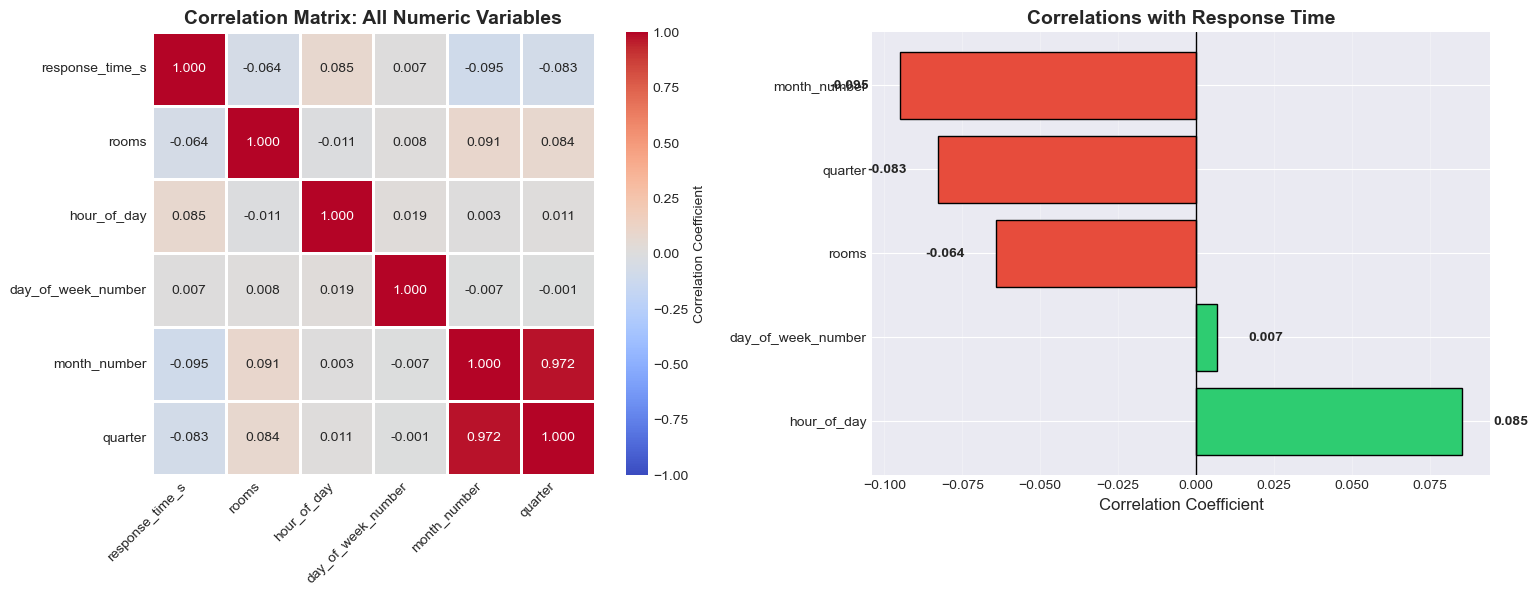


CORRELATION STRENGTH INTERPRETATION
Strong correlation: |r| > 0.5
Moderate correlation: 0.3 < |r| ≤ 0.5
Weak correlation: 0.1 < |r| ≤ 0.3
No correlation: |r| ≤ 0.1


In [25]:
# ==========================================
# 2.3.3 Correlation Heatmap - Numeric Variables
# ==========================================

# Seleccionar variables numéricas relevantes
numeric_vars = ['response_time_s', 'rooms', 'hour_of_day', 'day_of_week_number', 'month_number', 'quarter']

# Crear subset con variables numéricas
df_numeric = df_match[numeric_vars].dropna()

# Calcular matriz de correlación
correlation_matrix = df_numeric.corr()

print("="*60)
print("CORRELATION MATRIX - NUMERIC VARIABLES")
print("="*60)
print(correlation_matrix.round(3))

# Identificar correlaciones más fuertes con response_time_s
print("\n" + "="*60)
print("CORRELATIONS WITH RESPONSE TIME")
print("="*60)
response_corr = correlation_matrix['response_time_s'].sort_values(ascending=False)
print(response_corr)

# Crear visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ===== SUBPLOT 1: Full Correlation Heatmap =====
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'Correlation Coefficient'},
    ax=axes[0]
)
axes[0].set_title('Correlation Matrix: All Numeric Variables', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

# ===== SUBPLOT 2: Response Time Correlations (Bar Chart) =====
response_corr_subset = response_corr.drop('response_time_s')  # Excluir auto-correlación

colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in response_corr_subset.values]
axes[1].barh(range(len(response_corr_subset)), response_corr_subset.values, color=colors, edgecolor='black')
axes[1].set_yticks(range(len(response_corr_subset)))
axes[1].set_yticklabels(response_corr_subset.index)
axes[1].set_xlabel('Correlation Coefficient', fontsize=12)
axes[1].set_title('Correlations with Response Time', fontsize=14, fontweight='bold')
axes[1].axvline(x=0, color='black', linewidth=1)
axes[1].grid(axis='x', alpha=0.3)

# Agregar valores en las barras
for i, v in enumerate(response_corr_subset.values):
    axes[1].text(v + 0.01 if v > 0 else v - 0.01, i, f'{v:.3f}', 
                va='center', ha='left' if v > 0 else 'right', fontweight='bold')

plt.tight_layout()
plt.show()

# Interpretación de correlaciones
print("\n" + "="*60)
print("CORRELATION STRENGTH INTERPRETATION")
print("="*60)
print("Strong correlation: |r| > 0.5")
print("Moderate correlation: 0.3 < |r| ≤ 0.5")
print("Weak correlation: 0.1 < |r| ≤ 0.3")
print("No correlation: |r| ≤ 0.1")